# Task 4 — Link Prediction with R-GCN

This notebook implements **link prediction** on the MetaFam family knowledge graph using a **Relational Graph Convolutional Network (R-GCN)** with a **DistMult** scoring decoder.

## Approach

| Component | Description |
|-----------|-------------|
| **Encoder** | R-GCN — learns node embeddings by aggregating neighbour info with relation-specific weights |
| **Decoder** | DistMult — scores `(head, relation, tail)` as `h^T · diag(r) · t` |
| **Training** | Negative sampling with margin-based ranking loss |
| **Evaluation** | MRR, Hits@1, Hits@3, Hits@10 on held-out test triples |

## Outline
1. Data loading & train/val split
2. Graph construction (DGL)
3. R-GCN encoder + DistMult decoder
4. Training loop with negative sampling
5. Evaluation on test set
6. Loss & metrics visualisation

In [1]:
import sys
sys.path.insert(0, '..')

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# PyTorch Geometric for graph neural networks
import torch_geometric
from torch_geometric.nn import RGCNConv
from torch_geometric.data import Data

from src.metafam import DATA_DIR, load_triples as _load_triples_df, set_plot_style

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")

# ── Plot style ────────────────────────────────────────────────────────────
set_plot_style()


Using device: cpu
PyTorch version: 2.10.0+cpu
PyG version: 2.7.0


## 1. Data Loading & Preprocessing

In [2]:
# ── Load raw triples ──────────────────────────────────────────────────────
def load_triples(filepath):
    """Load triples from a MetaFam triples file as (head, relation, tail) tuples.
    Thin wrapper around src.metafam.load_triples (which returns a DataFrame) so
    the rest of this notebook keeps working with tuples/lists — data loading
    used to be duplicated (with its own open()/split() loop) across all four
    notebooks (4.1)."""
    return list(_load_triples_df(filepath).itertuples(index=False, name=None))

train_raw = load_triples(DATA_DIR / 'train.txt')
test_raw  = load_triples(DATA_DIR / 'test.txt')

print(f"Train triples: {len(train_raw):,}")
print(f"Test triples:  {len(test_raw):,}")
print(f"\nSample train: {train_raw[:3]}")
print(f"Sample test:  {test_raw[:3]}")


Train triples: 13,821
Test triples:  590

Sample train: [('olivia0', 'sisterOf', 'selina10'), ('olivia0', 'sisterOf', 'isabella11'), ('olivia0', 'sisterOf', 'oskar24')]
Sample test:  [('olivia0', 'motherOf', 'nico4'), ('katharina1', 'motherOf', 'olivia0'), ('emma7', 'motherOf', 'katharina1')]


In [3]:
# ── Build entity and relation vocabularies ───────────────────────────────
# We need mappings for ALL entities appearing in train OR test
all_triples = train_raw + test_raw
entities = sorted(set(h for h, r, t in all_triples) | set(t for h, r, t in all_triples))
relations = sorted(set(r for h, r, t in all_triples))

entity2id = {e: i for i, e in enumerate(entities)}
relation2id = {r: i for i, r in enumerate(relations)}
id2entity = {i: e for e, i in entity2id.items()}
id2relation = {i: r for r, i in relation2id.items()}

num_entities = len(entity2id)
num_relations = len(relation2id)

print(f"Entities:  {num_entities:,}")
print(f"Relations: {num_relations}")
print(f"\nRelation types: {relations}")

Entities:  1,316
Relations: 28

Relation types: ['auntOf', 'boyCousinOf', 'boyFirstCousinOnceRemovedOf', 'boySecondCousinOf', 'brotherOf', 'daughterOf', 'fatherOf', 'girlCousinOf', 'girlFirstCousinOnceRemovedOf', 'girlSecondCousinOf', 'granddaughterOf', 'grandfatherOf', 'grandmotherOf', 'grandsonOf', 'greatAuntOf', 'greatGranddaughterOf', 'greatGrandfatherOf', 'greatGrandmotherOf', 'greatGrandsonOf', 'greatUncleOf', 'motherOf', 'nephewOf', 'nieceOf', 'secondAuntOf', 'secondUncleOf', 'sisterOf', 'sonOf', 'uncleOf']


In [4]:
# ── Test-set relation coverage (3.2) ──────────────────────────────────────
# test.txt turns out to cover only a handful of the 28 relation types — see
# the breakdown below. Models train on all 28 relations, but every "test MRR /
# Hits@k" number in this notebook is scored ONLY on whichever relations
# test.txt actually contains. Keep this in mind reading the per-relation chart
# in §8 later — its bars are exactly these relations, and any claim that
# R-GCN "captures complex multi-relational patterns" is only as strong as
# what gets evaluated here (it isn't evaluated on siblings, cousins, or any
# multi-hop relation — only on immediate parent/child links, if that's what
# the counts below show).
test_rel_counts = pd.Series([r for _, r, _ in test_raw]).value_counts()
print(f"Test set covers {test_rel_counts.shape[0]} of {num_relations} relation types:\n")
print(test_rel_counts.to_string())


Test set covers 4 of 28 relation types:

sonOf         214
daughterOf    200
motherOf       88
fatherOf       88


In [5]:
# ── Convert triples to IDs ────────────────────────────────────────────────
def triples_to_ids(triples, entity2id, relation2id):
    """Convert (head_str, rel_str, tail_str) → (head_id, rel_id, tail_id)"""
    return [(entity2id[h], relation2id[r], entity2id[t]) for h, r, t in triples]

test_ids = triples_to_ids(test_raw, entity2id, relation2id)

# ── Split train into train/val (90/10) ────────────────────────────────────
# Derive both from an immutable source (1.6): the previous version did
# `random.shuffle(train_ids)` in place and then `train_ids = train_ids[val_size:]`,
# so re-running this cell shuffled-and-resliced the ALREADY-split list,
# silently shrinking train by another 10% on every re-run.
all_train_ids = triples_to_ids(train_raw, entity2id, relation2id)
rng = random.Random(SEED)
shuffled = all_train_ids[:]          # never mutate the source
rng.shuffle(shuffled)
val_size  = int(len(shuffled) * 0.1)
val_ids   = shuffled[:val_size]
train_ids = shuffled[val_size:]

print(f"Final splits:")
print(f"  Train: {len(train_ids):,} triples")
print(f"  Val:   {len(val_ids):,} triples")
print(f"  Test:  {len(test_ids):,} triples")

# Convert to tensors
train_triples = torch.LongTensor(train_ids)
val_triples   = torch.LongTensor(val_ids)
test_triples  = torch.LongTensor(test_ids)

print(f"\nTensor shapes: train={train_triples.shape}, val={val_triples.shape}, test={test_triples.shape}")


Final splits:
  Train: 12,439 triples
  Val:   1,382 triples
  Test:  590 triples

Tensor shapes: train=torch.Size([12439, 3]), val=torch.Size([1382, 3]), test=torch.Size([590, 3])


## 2. Graph Construction (PyTorch Geometric)

We build an edge index and edge type tensor for the R-GCN. We also add **inverse relations** to allow information flow in both directions.

In [6]:
# ── Build PyG graph from training triples ─────────────────────────────────
# We include inverse edges: for each (h, r, t), add (t, r+num_relations, h)
# This helps GNN propagate info in both directions

def build_edge_index(triples, num_relations):
    """
    Build edge_index and edge_type tensors with original + inverse edges.
    """
    src = triples[:, 0]
    rel = triples[:, 1]
    dst = triples[:, 2]
    
    # Add inverse edges
    src_all = torch.cat([src, dst])
    dst_all = torch.cat([dst, src])
    rel_all = torch.cat([rel, rel + num_relations])  # inverse relations
    
    edge_index = torch.stack([src_all, dst_all], dim=0)
    edge_type = rel_all
    
    return edge_index, edge_type

# Build graph from training data only
edge_index, edge_type = build_edge_index(train_triples, num_relations)
edge_index = edge_index.to(DEVICE)
edge_type = edge_type.to(DEVICE)

print(f"Training graph:")
print(f"  Nodes: {num_entities:,}")
print(f"  Edges: {edge_index.shape[1]:,} (includes inverse)")
print(f"  Edge types: {num_relations * 2} (original + inverse)")

Training graph:
  Nodes: 1,316
  Edges: 24,878 (includes inverse)
  Edge types: 56 (original + inverse)


## 3. R-GCN Model Definition

The model has two parts:
- **R-GCN Encoder**: Learns entity embeddings using relation-specific message passing
- **DistMult Decoder**: Scores triples as `score(h, r, t) = Σ_i h_i · r_i · t_i`

In [7]:
class RGCNEncoder(nn.Module):
    """
    R-GCN encoder that learns entity embeddings using PyTorch Geometric.
    Uses basis decomposition to reduce parameters.
    """
    def __init__(self, num_entities, num_relations, hidden_dim, num_layers=2, 
                 num_bases=None, dropout=0.2):
        super().__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations * 2  # include inverse
        self.hidden_dim = hidden_dim
        
        if num_bases is None:
            num_bases = min(num_relations, 10)
        
        # Initial entity embeddings (learnable)
        self.entity_embedding = nn.Embedding(num_entities, hidden_dim)
        nn.init.xavier_uniform_(self.entity_embedding.weight)
        
        # R-GCN layers
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            self.convs.append(
                RGCNConv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim,
                    num_relations=self.num_relations,
                    num_bases=num_bases
                )
            )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, edge_index, edge_type):
        """
        Args:
            edge_index: [2, num_edges]
            edge_type: [num_edges]
        Returns:
            Entity embeddings [num_entities, hidden_dim]
        """
        h = self.entity_embedding.weight
        
        for i, conv in enumerate(self.convs):
            h = conv(h, edge_index, edge_type)
            if i < len(self.convs) - 1:  # No activation OR dropout on the final layer (4.6) —
                h = F.relu(h)            # embeddings fed to the decoder shouldn't be noised.
                h = self.dropout(h)
        
        return h


class DistMultDecoder(nn.Module):
    """
    DistMult scoring function: score(h, r, t) = h^T diag(r) t = Σ h_i * r_i * t_i
    """
    def __init__(self, num_relations, hidden_dim):
        super().__init__()
        # Only original relations (not inverse) for scoring
        self.relation_embedding = nn.Embedding(num_relations, hidden_dim)
        nn.init.xavier_uniform_(self.relation_embedding.weight)
    
    def forward(self, entity_emb, heads, relations, tails):
        """
        Score triples.
        Args:
            entity_emb: [num_entities, hidden_dim]
            heads, relations, tails: [batch_size] tensors of IDs
        Returns:
            scores: [batch_size]
        """
        h = entity_emb[heads]  # [batch, dim]
        r = self.relation_embedding(relations)  # [batch, dim]
        t = entity_emb[tails]  # [batch, dim]
        
        # DistMult: element-wise product then sum
        scores = (h * r * t).sum(dim=1)
        return scores
    
    def score_all_tails(self, entity_emb, heads, relations):
        """
        Score all possible tails for given (head, relation) pairs.
        Used for ranking evaluation.
        """
        h = entity_emb[heads]  # [batch, dim]
        r = self.relation_embedding(relations)  # [batch, dim]
        
        # h * r: [batch, dim]
        # entity_emb: [num_entities, dim]
        # scores: [batch, num_entities]
        scores = (h * r) @ entity_emb.T
        return scores
    
    def score_all_heads(self, entity_emb, relations, tails):
        """
        Score all possible heads for given (relation, tail) pairs.
        """
        r = self.relation_embedding(relations)  # [batch, dim]
        t = entity_emb[tails]  # [batch, dim]
        
        # r * t: [batch, dim]
        scores = (r * t) @ entity_emb.T
        return scores


class LinkPredictor(nn.Module):
    """Complete link prediction model: R-GCN encoder + DistMult decoder"""
    def __init__(self, num_entities, num_relations, hidden_dim, num_layers=2,
                 num_bases=None, dropout=0.2):
        super().__init__()
        self.encoder = RGCNEncoder(num_entities, num_relations, hidden_dim,
                                   num_layers, num_bases, dropout)
        self.decoder = DistMultDecoder(num_relations, hidden_dim)
        self.num_entities = num_entities
    
    def forward(self, edge_index, edge_type, heads, relations, tails):
        """Forward pass: encode then score"""
        entity_emb = self.encoder(edge_index, edge_type)
        scores = self.decoder(entity_emb, heads, relations, tails)
        return scores, entity_emb
    
    def get_embeddings(self, edge_index, edge_type):
        """Get entity embeddings only"""
        return self.encoder(edge_index, edge_type)

print("Model classes defined ✓")

Model classes defined ✓


## 4. Training Setup

We use:
- **Negative sampling**: For each positive triple (h, r, t), corrupt either head or tail
- **Margin ranking loss**: `loss = max(0, margin - score_pos + score_neg)`
- **Filtered evaluation**: Don't penalise if corrupted triple exists in dataset

In [8]:
# ── Negative Sampling ─────────────────────────────────────────────────────
class TripleDataset(Dataset):
    """Dataset that returns positive triples"""
    def __init__(self, triples):
        self.triples = triples

    def __len__(self):
        return len(self.triples)

    def __getitem__(self, idx):
        return self.triples[idx]


def generate_negatives(pos_triples, num_entities, num_neg=1):
    """
    Generate negative samples by corrupting head or tail.

    Pairing contract (1.1): block i of the returned negatives (rows
    [i*num_neg, (i+1)*num_neg)) must corrupt pos_triples[i] — this has to
    match pos_scores.repeat_interleave(num_neg), which is how every training
    loop below expands the positives to pair against these negatives.
    repeat_interleave blocks: [a,b,c] → [a,a,b,b,c,c]. repeat/tile does NOT:
    [a,b,c] → [a,b,c,a,b,c], which pairs positive i against negatives derived
    from OTHER positives (see IMPROVEMENT_PLAN.md 1.1).
    """
    batch_size = pos_triples.shape[0]
    heads, rels, tails = pos_triples[:, 0], pos_triples[:, 1], pos_triples[:, 2]

    neg_heads = heads.repeat_interleave(num_neg)
    neg_rels = rels.repeat_interleave(num_neg)
    neg_tails = tails.repeat_interleave(num_neg)

    # Corrupt head or tail with 50% probability each
    mask = torch.rand(batch_size * num_neg) < 0.5
    random_entities = torch.randint(0, num_entities, (batch_size * num_neg,))

    neg_heads = torch.where(mask, random_entities, neg_heads)
    neg_tails = torch.where(~mask, random_entities, neg_tails)

    neg_batch = torch.stack([neg_heads, neg_rels, neg_tails], dim=1)
    assert neg_batch.shape[0] == pos_triples.shape[0] * num_neg
    return neg_batch


# ── Fast filtered-evaluation lookups (4.2) ─────────────────────────────────
# Both evaluate() and evaluate_transe() used to filter with a pure-Python
# double loop over every candidate entity (~168k set lookups per batch per
# direction, every validation pass). Precompute the KNOWN completions once and
# only touch those (orders of magnitude fewer lookups, identical results).
hr_to_tails = defaultdict(set)   # (h, r) -> {t}
rt_to_heads = defaultdict(set)   # (r, t) -> {h}
for h, r, t in train_ids + val_ids + test_ids:
    hr_to_tails[(h, r)].add(t)
    rt_to_heads[(r, t)].add(h)

print(f"Filtering lookups built: {len(hr_to_tails):,} (h,r) keys, {len(rt_to_heads):,} (r,t) keys")


Filtering lookups built: 6,145 (h,r) keys, 9,964 (r,t) keys


In [9]:
# ── Evaluation Metrics ────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_ranks(score_all_tails_fn, score_all_heads_fn, triples, batch_size=128):
    """
    Compute MRR, Hits@1, Hits@3, Hits@10 with filtered ranking, given scoring
    callables. Shared by the R-GCN and TransE evaluate wrappers below, which
    differ only in how they call score_all_tails / score_all_heads (4.2, 4.4).

    Rank convention (3.7): (scores >= true_score).sum() is the PESSIMISTIC
    rank — a tied score counts against the model (worst-case rank, not best-
    case). Defensible and standard, but not universal — results aren\'t
    directly comparable to a paper that uses a different tie-break without
    checking which one it reports.
    """
    ranks = []

    for start in range(0, len(triples), batch_size):
        batch = triples[start:start + batch_size].to(DEVICE)
        heads, rels, tails = batch[:, 0], batch[:, 1], batch[:, 2]

        # ── Tail prediction ───────────────────────────────────────────────
        scores_tail = score_all_tails_fn(heads, rels)
        for i, (h, r, t) in enumerate(batch.tolist()):
            known = hr_to_tails[(h, r)] - {t}
            if known:
                scores_tail[i, list(known)] = float('-inf')

        true_scores_tail = scores_tail[torch.arange(len(batch), device=DEVICE), tails]
        ranks_tail = (scores_tail >= true_scores_tail.unsqueeze(1)).sum(dim=1)

        # ── Head prediction ───────────────────────────────────────────────
        scores_head = score_all_heads_fn(rels, tails)
        for i, (h, r, t) in enumerate(batch.tolist()):
            known = rt_to_heads[(r, t)] - {h}
            if known:
                scores_head[i, list(known)] = float('-inf')

        true_scores_head = scores_head[torch.arange(len(batch), device=DEVICE), heads]
        ranks_head = (scores_head >= true_scores_head.unsqueeze(1)).sum(dim=1)

        ranks.extend(ranks_tail.tolist())
        ranks.extend(ranks_head.tolist())

    ranks = torch.tensor(ranks, dtype=torch.float)

    return {
        'MRR': (1.0 / ranks).mean().item(),
        'Hits@1': (ranks <= 1).float().mean().item(),
        'Hits@3': (ranks <= 3).float().mean().item(),
        'Hits@10': (ranks <= 10).float().mean().item(),
        'Mean Rank': ranks.mean().item(),
    }


@torch.no_grad()
def evaluate(model, edge_index, edge_type, triples, batch_size=128):
    """R-GCN + DistMult evaluate: compute entity embeddings once, then rank."""
    model.eval()
    entity_emb = model.get_embeddings(edge_index, edge_type)
    return evaluate_ranks(
        lambda h, r: model.decoder.score_all_tails(entity_emb, h, r),
        lambda r, t: model.decoder.score_all_heads(entity_emb, r, t),
        triples, batch_size,
    )

print("Evaluation function defined ✓")


Evaluation function defined ✓


## 5. Training Loop

In [10]:
# ── Hyperparameters ───────────────────────────────────────────────────────
HIDDEN_DIM = 200
NUM_LAYERS = 2
NUM_BASES = 10
DROPOUT = 0.2
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 150
BATCH_SIZE = 1024
NUM_NEG = 10  # negative samples per positive
MARGIN = 1.0
EVAL_EVERY = 10

print("Hyperparameters:")
print(f"  Hidden dim:     {HIDDEN_DIM}")
print(f"  R-GCN layers:   {NUM_LAYERS}")
print(f"  Num bases:      {NUM_BASES}")
print(f"  Dropout:        {DROPOUT}")
print(f"  Learning rate:  {LEARNING_RATE}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Neg samples:    {NUM_NEG}")
print(f"  Margin:         {MARGIN}")
print(f"  Epochs:         {NUM_EPOCHS}")

Hyperparameters:
  Hidden dim:     200
  R-GCN layers:   2
  Num bases:      10
  Dropout:        0.2
  Learning rate:  0.01
  Batch size:     1024
  Neg samples:    10
  Margin:         1.0
  Epochs:         150


In [11]:
# ── Initialize model ──────────────────────────────────────────────────────
model = LinkPredictor(
    num_entities=num_entities,
    num_relations=num_relations,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_bases=NUM_BASES,
    dropout=DROPOUT
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} total, {trainable_params:,} trainable")

Model parameters: 1,150,320 total, 1,150,320 trainable


In [12]:
# ── Training loop ─────────────────────────────────────────────────────────
train_dataset = TripleDataset(train_triples)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

history = {
    'epoch': [],
    'train_loss': [],
    'val_mrr': [],
    'val_hits1': [],
    'val_hits10': []
}

best_val_mrr = 0.0
best_model_state = None

print(f"Starting training for {NUM_EPOCHS} epochs...")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in train_loader:
        batch = batch.to(DEVICE)
        
        # Generate negative samples
        neg_batch = generate_negatives(batch.cpu(), num_entities, NUM_NEG).to(DEVICE)
        
        # Forward pass - positive
        pos_heads, pos_rels, pos_tails = batch[:, 0], batch[:, 1], batch[:, 2]
        pos_scores, entity_emb = model(edge_index, edge_type, pos_heads, pos_rels, pos_tails)
        
        # Forward pass - negative (reuse entity embeddings)
        neg_heads, neg_rels, neg_tails = neg_batch[:, 0], neg_batch[:, 1], neg_batch[:, 2]
        neg_scores = model.decoder(entity_emb, neg_heads, neg_rels, neg_tails)
        
        # Reshape for margin loss: each positive paired with NUM_NEG negatives
        pos_scores_exp = pos_scores.repeat_interleave(NUM_NEG)
        
        # Margin ranking loss
        loss = F.margin_ranking_loss(
            pos_scores_exp, neg_scores,
            target=torch.ones_like(pos_scores_exp),
            margin=MARGIN
        )
        
        # No separate L2 term here (4.6): the Adam optimizer already applies
        # weight_decay=WEIGHT_DECAY below, and the removed manual L2 term
        # (0.01 * ... / num_entities ≈ 7.6e-6) was redundant with it.
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    history['epoch'].append(epoch)
    history['train_loss'].append(avg_loss)
    
    # Evaluate on validation set periodically
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        val_metrics = evaluate(model, edge_index, edge_type, val_triples)
        history['val_mrr'].append(val_metrics['MRR'])
        history['val_hits1'].append(val_metrics['Hits@1'])
        history['val_hits10'].append(val_metrics['Hits@10'])
        
        scheduler.step(val_metrics['MRR'])
        
        # Save best model
        if val_metrics['MRR'] > best_val_mrr:
            best_val_mrr = val_metrics['MRR']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | "
              f"Val MRR: {val_metrics['MRR']:.4f} | Hits@1: {val_metrics['Hits@1']:.4f} | "
              f"Hits@10: {val_metrics['Hits@10']:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
    else:
        history['val_mrr'].append(None)
        history['val_hits1'].append(None)
        history['val_hits10'].append(None)

print("-" * 70)
print(f"Training complete! Best Val MRR: {best_val_mrr:.4f}")

Starting training for 150 epochs...
----------------------------------------------------------------------


Epoch   1 | Loss: 0.4613 | Val MRR: 0.1564 | Hits@1: 0.0843 | Hits@10: 0.2931 | LR: 0.010000


Epoch  10 | Loss: 0.0048 | Val MRR: 0.6559 | Hits@1: 0.4924 | Hits@10: 0.9472 | LR: 0.010000


Epoch  20 | Loss: 0.0043 | Val MRR: 0.7027 | Hits@1: 0.5532 | Hits@10: 0.9707 | LR: 0.010000


Epoch  30 | Loss: 0.0047 | Val MRR: 0.6810 | Hits@1: 0.5311 | Hits@10: 0.9667 | LR: 0.010000


...

Epoch 110 | Loss: 0.0094 | Val MRR: 0.5531 | Hits@1: 0.3799 | Hits@10: 0.8947 | LR: 0.010000


Epoch 120 | Loss: 0.0053 | Val MRR: 0.6964 | Hits@1: 0.5384 | Hits@10: 0.9794 | LR: 0.010000


Epoch 130 | Loss: 0.0038 | Val MRR: 0.7106 | Hits@1: 0.5604 | Hits@10: 0.9819 | LR: 0.010000


Epoch 140 | Loss: 0.0047 | Val MRR: 0.6804 | Hits@1: 0.5250 | Hits@10: 0.9627 | LR: 0.010000


Epoch 150 | Loss: 0.0051 | Val MRR: 0.6836 | Hits@1: 0.5224 | Hits@10: 0.9761 | LR: 0.010000
----------------------------------------------------------------------
Training complete! Best Val MRR: 0.7127


## 6. Test Set Evaluation

In [13]:
# ── Load best model and evaluate on test set ──────────────────────────────
if best_model_state is not None:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})
    print("Loaded best model based on validation MRR\n")

test_metrics = evaluate(model, edge_index, edge_type, test_triples)

print("=" * 50)
print("        TEST SET RESULTS (Filtered)")
print("=" * 50)
print(f"  MRR:        {test_metrics['MRR']:.4f}")
print(f"  Hits@1:     {test_metrics['Hits@1']:.4f}")
print(f"  Hits@3:     {test_metrics['Hits@3']:.4f}")
print(f"  Hits@10:    {test_metrics['Hits@10']:.4f}")
print(f"  Mean Rank:  {test_metrics['Mean Rank']:.1f}")
print("=" * 50)

Loaded best model based on validation MRR



        TEST SET RESULTS (Filtered)
  MRR:        0.5426
  Hits@1:     0.3441
  Hits@3:     0.6780
  Hits@10:    0.9466
  Mean Rank:  4.6


## 7. Training Visualisation

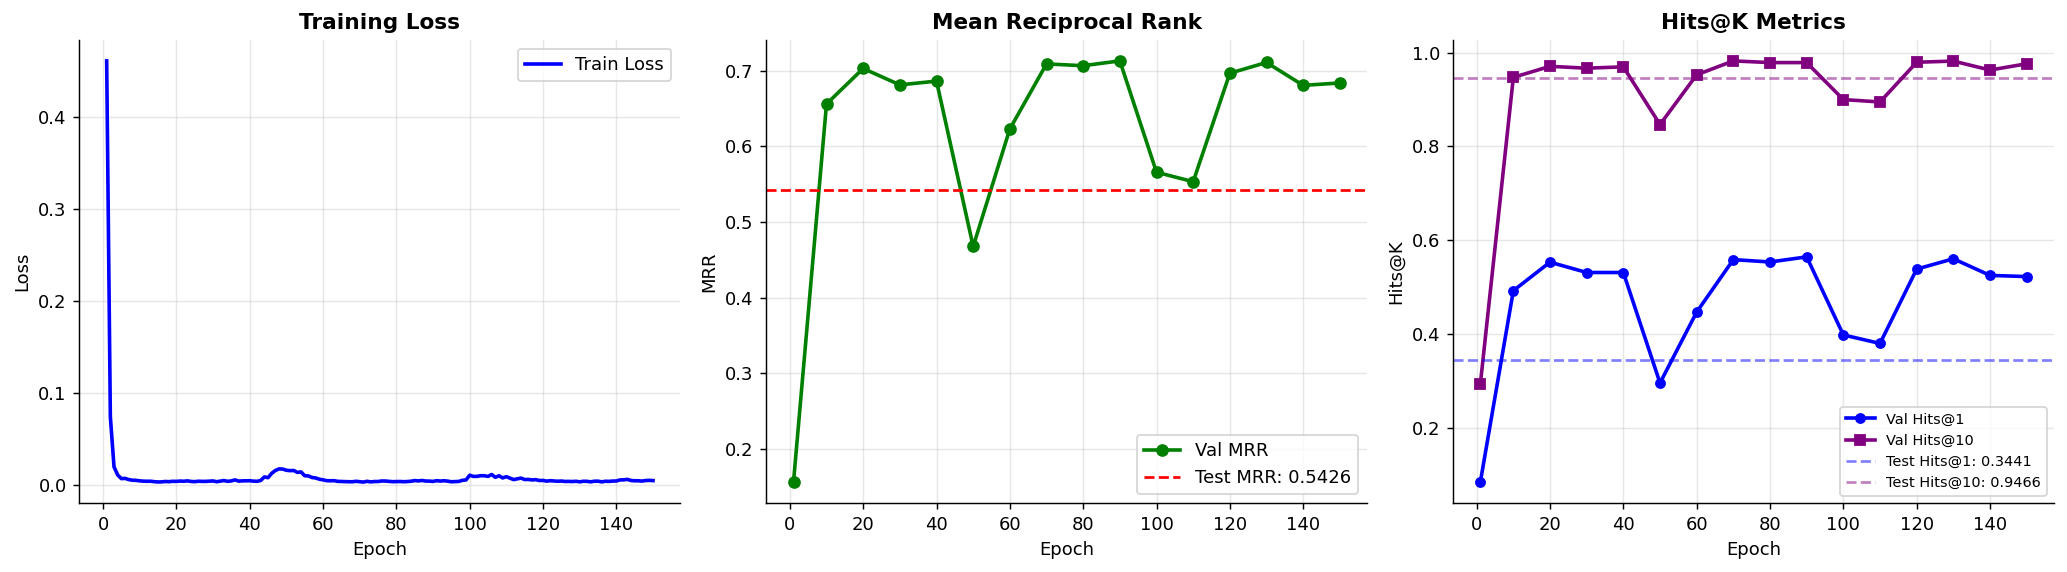

Training curves saved to images/task4/rgcn_training_curves.png


In [14]:
# ── Plot training curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Loss curve
axes[0].plot(history['epoch'], history['train_loss'], 'b-', linewidth=2, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MRR curve (only at evaluation points)
eval_epochs = [e for e, m in zip(history['epoch'], history['val_mrr']) if m is not None]
val_mrrs = [m for m in history['val_mrr'] if m is not None]
axes[1].plot(eval_epochs, val_mrrs, 'g-o', linewidth=2, markersize=6, label='Val MRR')
axes[1].axhline(test_metrics['MRR'], color='r', linestyle='--', label=f"Test MRR: {test_metrics['MRR']:.4f}")
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MRR')
axes[1].set_title('Mean Reciprocal Rank')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Hits@K curves
val_hits1 = [m for m in history['val_hits1'] if m is not None]
val_hits10 = [m for m in history['val_hits10'] if m is not None]
axes[2].plot(eval_epochs, val_hits1, 'b-o', linewidth=2, markersize=5, label='Val Hits@1')
axes[2].plot(eval_epochs, val_hits10, 'purple', linestyle='-', marker='s', linewidth=2, markersize=5, label='Val Hits@10')
axes[2].axhline(test_metrics['Hits@1'], color='b', linestyle='--', alpha=0.5, label=f"Test Hits@1: {test_metrics['Hits@1']:.4f}")
axes[2].axhline(test_metrics['Hits@10'], color='purple', linestyle='--', alpha=0.5, label=f"Test Hits@10: {test_metrics['Hits@10']:.4f}")
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Hits@K')
axes[2].set_title('Hits@K Metrics')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task4/rgcn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to images/task4/rgcn_training_curves.png")

## 8. Per-Relation Analysis

Let's see how the model performs on different relation types.

In [15]:
# ── Per-relation metrics on test set ──────────────────────────────────────
@torch.no_grad()
def evaluate_per_relation(model, edge_index, edge_type, triples, id2relation):
    """Compute metrics grouped by relation type (same fast filtering as evaluate_ranks, 4.2)."""
    model.eval()
    entity_emb = model.get_embeddings(edge_index, edge_type)

    rel_ranks = defaultdict(list)

    for triple in triples:
        h, r, t = triple.tolist()
        triple_batch = triple.unsqueeze(0).to(DEVICE)

        # Tail prediction
        scores_tail = model.decoder.score_all_tails(entity_emb,
                                                     triple_batch[:, 0],
                                                     triple_batch[:, 1])
        known_t = hr_to_tails[(h, r)] - {t}
        if known_t:
            scores_tail[0, list(known_t)] = float('-inf')

        true_score = scores_tail[0, t]
        rank_tail = (scores_tail[0] >= true_score).sum().item()

        # Head prediction
        scores_head = model.decoder.score_all_heads(entity_emb,
                                                     triple_batch[:, 1],
                                                     triple_batch[:, 2])
        known_h = rt_to_heads[(r, t)] - {h}
        if known_h:
            scores_head[0, list(known_h)] = float('-inf')

        true_score = scores_head[0, h]
        rank_head = (scores_head[0] >= true_score).sum().item()

        rel_name = id2relation[r]
        rel_ranks[rel_name].extend([rank_tail, rank_head])

    # Compute metrics per relation
    results = []
    for rel_name, ranks in rel_ranks.items():
        ranks = torch.tensor(ranks, dtype=torch.float)
        results.append({
            'Relation': rel_name,
            'Count': len(ranks) // 2,  # each triple contributes 2 ranks
            'MRR': (1.0 / ranks).mean().item(),
            'Hits@1': (ranks <= 1).float().mean().item(),
            'Hits@10': (ranks <= 10).float().mean().item(),
        })

    return pd.DataFrame(results).sort_values('MRR', ascending=False)

print("Computing per-relation metrics on test set...")
per_rel_df = evaluate_per_relation(model, edge_index, edge_type, test_triples, id2relation)
print(per_rel_df.to_string(index=False))


Computing per-relation metrics on test set...


  Relation  Count      MRR   Hits@1  Hits@10
  fatherOf     88 0.643416 0.477273 0.982955
  motherOf     88 0.553328 0.340909 0.982955
     sonOf    214 0.526593 0.320093 0.953271
daughterOf    200 0.510618 0.312500 0.907500


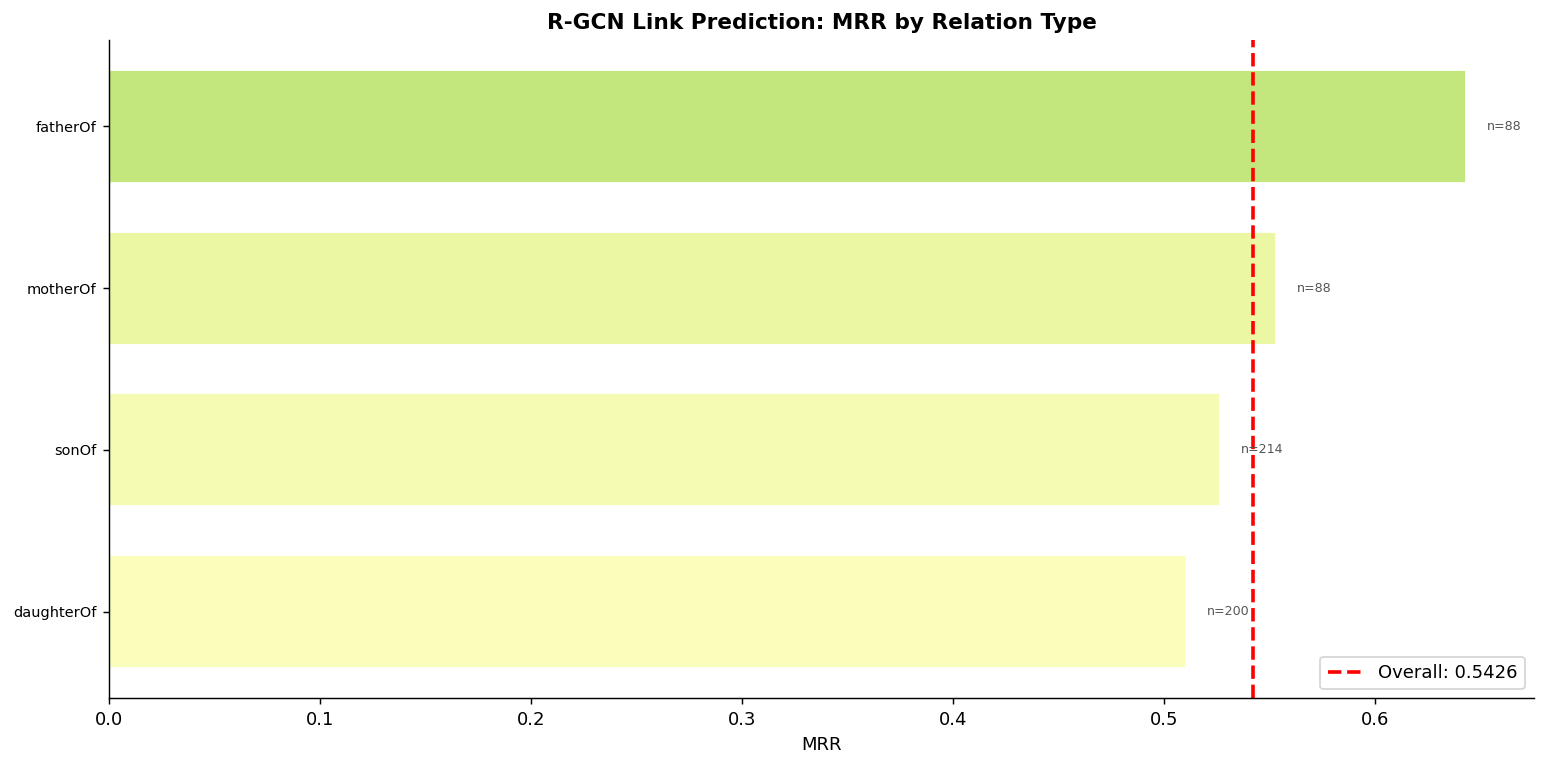

In [16]:
# ── Visualize per-relation performance ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by MRR for visualization
df_sorted = per_rel_df.sort_values('MRR')
y_pos = range(len(df_sorted))

colors = plt.cm.RdYlGn(df_sorted['MRR'].values)
bars = ax.barh(y_pos, df_sorted['MRR'], color=colors, edgecolor='white', height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(df_sorted['Relation'], fontsize=8)
ax.set_xlabel('MRR')
ax.set_title('R-GCN Link Prediction: MRR by Relation Type')
ax.axvline(test_metrics['MRR'], color='red', linestyle='--', linewidth=2, 
           label=f"Overall: {test_metrics['MRR']:.4f}")
ax.legend(loc='lower right')

# Add count annotations
for i, (mrr, count) in enumerate(zip(df_sorted['MRR'], df_sorted['Count'])):
    ax.text(mrr + 0.01, i, f'n={count}', va='center', fontsize=7, color='#555')

plt.tight_layout()
plt.savefig('../images/task4/rgcn_per_relation_mrr.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary

### Model Architecture
- **Encoder**: 2-layer R-GCN with basis decomposition (10 bases)
- **Decoder**: DistMult bilinear scoring function
- **Training**: Margin ranking loss with negative sampling

### Key Design Decisions
1. **Inverse relations**: Added inverse edges to allow bidirectional message passing
2. **Basis decomposition**: Reduces parameters for relation-specific weights
3. **Filtered evaluation**: Standard protocol — don't penalise correct predictions
4. **Train/Val/Test split**: 90%/10% of train.txt for training/validation, test.txt for final evaluation
5. **Test-set coverage (3.2)**: test.txt contains only a handful of the 28 relations (see the breakdown printed in §1) — every test metric in this notebook, including the per-relation chart below, is scored only on those relations, not on the full relational vocabulary the models train on.

### Results Table

In [17]:
# ── Final summary table ───────────────────────────────────────────────────
summary_df = pd.DataFrame([{
    'Model': 'R-GCN + DistMult',
    'MRR': test_metrics['MRR'],
    'Hits@1': test_metrics['Hits@1'],
    'Hits@3': test_metrics['Hits@3'],
    'Hits@10': test_metrics['Hits@10'],
    'Mean Rank': test_metrics['Mean Rank']
}])

print("\n" + "=" * 60)
print("                 FINAL TEST RESULTS")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'entity2id': entity2id,
    'relation2id': relation2id,
    'hyperparameters': {
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'num_bases': NUM_BASES,
        'dropout': DROPOUT
    },
    'test_metrics': test_metrics
}, '../models/rgcn_link_predictor.pt')

print("\nModel saved to models/rgcn_link_predictor.pt")


                 FINAL TEST RESULTS
           Model     MRR   Hits@1   Hits@3  Hits@10  Mean Rank
R-GCN + DistMult 0.54259 0.344068 0.677966  0.94661   4.618644

Model saved to models/rgcn_link_predictor.pt


---

# Part B: TransE — Knowledge Graph Embedding Baseline

TransE is a classic **translational** KG embedding method. Unlike R-GCN which uses graph neural networks to learn embeddings from the graph structure, TransE learns embeddings directly from the triples.

## Key Idea

For a true triple $(h, r, t)$, TransE models the relation as a **translation** in embedding space:

$$\mathbf{h} + \mathbf{r} \approx \mathbf{t}$$

The scoring function is the **negative L1/L2 distance**:
$$\text{score}(h, r, t) = -||\mathbf{h} + \mathbf{r} - \mathbf{t}||$$

Higher score (closer to 0) = more likely to be true.

In [18]:
# ══════════════════════════════════════════════════════════════════════════
#                           TRANSE MODEL
# ══════════════════════════════════════════════════════════════════════════

class TransE(nn.Module):
    """
    TransE: Translating Embeddings for Modeling Multi-relational Data
    
    Idea: h + r ≈ t for true triples
    Score: -||h + r - t|| (higher = better, closer to 0)
    """
    def __init__(self, num_entities, num_relations, embedding_dim, norm=1):
        super().__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim
        self.norm = norm  # L1 or L2 norm
        
        # Entity and relation embeddings
        self.entity_embedding = nn.Embedding(num_entities, embedding_dim)
        self.relation_embedding = nn.Embedding(num_relations, embedding_dim)
        
        # Initialize embeddings
        nn.init.xavier_uniform_(self.entity_embedding.weight)
        nn.init.xavier_uniform_(self.relation_embedding.weight)
        
        # Normalize relation embeddings to unit length
        with torch.no_grad():
            self.relation_embedding.weight.data = F.normalize(
                self.relation_embedding.weight.data, p=2, dim=1
            )
    
    def forward(self, heads, relations, tails):
        """
        Compute TransE scores for triples.
        Returns: negative distance (higher = better)
        """
        h = self.entity_embedding(heads)
        r = self.relation_embedding(relations)
        t = self.entity_embedding(tails)
        
        # score = -||h + r - t||
        scores = -torch.norm(h + r - t, p=self.norm, dim=1)
        return scores
    
    def score_all_tails(self, heads, relations):
        """Score all possible tails for (head, relation, ?)"""
        h = self.entity_embedding(heads)  # [batch, dim]
        r = self.relation_embedding(relations)  # [batch, dim]
        all_t = self.entity_embedding.weight  # [num_entities, dim]
        
        # h + r: [batch, dim]
        # We want: -||h + r - t|| for all t
        # = -||(h + r).unsqueeze(1) - all_t.unsqueeze(0)||
        hr = (h + r).unsqueeze(1)  # [batch, 1, dim]
        all_t_exp = all_t.unsqueeze(0)  # [1, num_entities, dim]
        
        scores = -torch.norm(hr - all_t_exp, p=self.norm, dim=2)  # [batch, num_entities]
        return scores
    
    def score_all_heads(self, relations, tails):
        """Score all possible heads for (?, relation, tail)"""
        r = self.relation_embedding(relations)  # [batch, dim]
        t = self.entity_embedding(tails)  # [batch, dim]
        all_h = self.entity_embedding.weight  # [num_entities, dim]
        
        # We want: -||h + r - t|| = -||h - (t - r)||
        tr = (t - r).unsqueeze(1)  # [batch, 1, dim]
        all_h_exp = all_h.unsqueeze(0)  # [1, num_entities, dim]
        
        scores = -torch.norm(all_h_exp - tr, p=self.norm, dim=2)  # [batch, num_entities]
        return scores

print("TransE model class defined ✓")

TransE model class defined ✓


In [19]:
# ── TransE Evaluation Function ────────────────────────────────────────────
@torch.no_grad()
def evaluate_transe(model, triples, batch_size=128):
    """TransE evaluate — same fast filtered ranking as evaluate() above (4.2, 4.4)."""
    model.eval()
    return evaluate_ranks(model.score_all_tails, model.score_all_heads, triples, batch_size)

print("TransE evaluation function defined ✓")


TransE evaluation function defined ✓


In [20]:
# ── TransE Hyperparameters ────────────────────────────────────────────────
TRANSE_EMB_DIM = 200
TRANSE_NORM = 1  # L1 norm (Manhattan distance)
TRANSE_LR = 0.01
TRANSE_MARGIN = 1.0
TRANSE_EPOCHS = 200
TRANSE_BATCH_SIZE = 1024
TRANSE_NUM_NEG = 10

# Initialize TransE model
transe_model = TransE(
    num_entities=num_entities,
    num_relations=num_relations,
    embedding_dim=TRANSE_EMB_DIM,
    norm=TRANSE_NORM
).to(DEVICE)

transe_optimizer = torch.optim.Adam(transe_model.parameters(), lr=TRANSE_LR)
transe_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    transe_optimizer, mode='max', factor=0.5, patience=15
)

transe_params = sum(p.numel() for p in transe_model.parameters())
print(f"TransE parameters: {transe_params:,}")
print(f"  (Compare to R-GCN: {total_params:,})")
print(f"\nHyperparameters:")
print(f"  Embedding dim: {TRANSE_EMB_DIM}")
print(f"  Norm: L{TRANSE_NORM}")
print(f"  Learning rate: {TRANSE_LR}")
print(f"  Margin: {TRANSE_MARGIN}")
print(f"  Epochs: {TRANSE_EPOCHS}")

TransE parameters: 268,800
  (Compare to R-GCN: 1,150,320)

Hyperparameters:
  Embedding dim: 200
  Norm: L1
  Learning rate: 0.01
  Margin: 1.0
  Epochs: 200


In [21]:
# ── TransE Training Loop ──────────────────────────────────────────────────
transe_history = {
    'epoch': [],
    'train_loss': [],
    'val_mrr': [],
    'val_hits1': [],
    'val_hits10': []
}

best_transe_mrr = 0.0
best_transe_state = None

print(f"Training TransE for {TRANSE_EPOCHS} epochs...")
print("-" * 70)

import time
start_time = time.time()

for epoch in range(1, TRANSE_EPOCHS + 1):
    transe_model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in train_loader:
        batch = batch.to(DEVICE)
        
        # Generate negative samples (same as R-GCN)
        neg_batch = generate_negatives(batch.cpu(), num_entities, TRANSE_NUM_NEG).to(DEVICE)
        
        # Positive scores
        pos_heads, pos_rels, pos_tails = batch[:, 0], batch[:, 1], batch[:, 2]
        pos_scores = transe_model(pos_heads, pos_rels, pos_tails)
        
        # Negative scores
        neg_heads, neg_rels, neg_tails = neg_batch[:, 0], neg_batch[:, 1], neg_batch[:, 2]
        neg_scores = transe_model(neg_heads, neg_rels, neg_tails)
        
        # Margin ranking loss
        pos_scores_exp = pos_scores.repeat_interleave(TRANSE_NUM_NEG)
        loss = F.margin_ranking_loss(
            pos_scores_exp, neg_scores,
            target=torch.ones_like(pos_scores_exp),
            margin=TRANSE_MARGIN
        )
        
        # Normalize entity embeddings after each batch (important for TransE)
        transe_optimizer.zero_grad()
        loss.backward()
        transe_optimizer.step()
        
        # Re-normalize entity embeddings to prevent explosion
        with torch.no_grad():
            transe_model.entity_embedding.weight.data = F.normalize(
                transe_model.entity_embedding.weight.data, p=2, dim=1
            )
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    transe_history['epoch'].append(epoch)
    transe_history['train_loss'].append(avg_loss)
    
    # Evaluate periodically
    if epoch % 20 == 0 or epoch == 1:
        val_metrics = evaluate_transe(transe_model, val_triples)
        transe_history['val_mrr'].append(val_metrics['MRR'])
        transe_history['val_hits1'].append(val_metrics['Hits@1'])
        transe_history['val_hits10'].append(val_metrics['Hits@10'])
        
        transe_scheduler.step(val_metrics['MRR'])
        
        if val_metrics['MRR'] > best_transe_mrr:
            best_transe_mrr = val_metrics['MRR']
            best_transe_state = {k: v.cpu().clone() for k, v in transe_model.state_dict().items()}
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | "
              f"Val MRR: {val_metrics['MRR']:.4f} | Hits@1: {val_metrics['Hits@1']:.4f} | "
              f"Hits@10: {val_metrics['Hits@10']:.4f}")
    else:
        transe_history['val_mrr'].append(None)
        transe_history['val_hits1'].append(None)
        transe_history['val_hits10'].append(None)

elapsed = time.time() - start_time
print("-" * 70)
print(f"TransE training complete in {elapsed:.1f}s! Best Val MRR: {best_transe_mrr:.4f}")

Training TransE for 200 epochs...
----------------------------------------------------------------------


Epoch   1 | Loss: 0.7477 | Val MRR: 0.0723 | Hits@1: 0.0000 | Hits@10: 0.2218


Epoch  20 | Loss: 0.0062 | Val MRR: 0.3147 | Hits@1: 0.0894 | Hits@10: 0.8470


Epoch  40 | Loss: 0.0065 | Val MRR: 0.3930 | Hits@1: 0.1686 | Hits@10: 0.8839


Epoch  60 | Loss: 0.0080 | Val MRR: 0.3803 | Hits@1: 0.1469 | Hits@10: 0.8886


...

Epoch 120 | Loss: 0.0119 | Val MRR: 0.3368 | Hits@1: 0.1089 | Hits@10: 0.8578


Epoch 140 | Loss: 0.0107 | Val MRR: 0.3495 | Hits@1: 0.1281 | Hits@10: 0.8647


Epoch 160 | Loss: 0.0099 | Val MRR: 0.3838 | Hits@1: 0.1603 | Hits@10: 0.8810


Epoch 180 | Loss: 0.0104 | Val MRR: 0.3671 | Hits@1: 0.1393 | Hits@10: 0.8629


Epoch 200 | Loss: 0.0099 | Val MRR: 0.3419 | Hits@1: 0.1136 | Hits@10: 0.8643
----------------------------------------------------------------------
TransE training complete in 69.0s! Best Val MRR: 0.3930


In [22]:
# ── TransE Test Evaluation ────────────────────────────────────────────────
if best_transe_state is not None:
    transe_model.load_state_dict({k: v.to(DEVICE) for k, v in best_transe_state.items()})
    print("Loaded best TransE model based on validation MRR\n")

transe_test_metrics = evaluate_transe(transe_model, test_triples)

print("=" * 50)
print("     TRANSE TEST SET RESULTS (Filtered)")
print("=" * 50)
print(f"  MRR:        {transe_test_metrics['MRR']:.4f}")
print(f"  Hits@1:     {transe_test_metrics['Hits@1']:.4f}")
print(f"  Hits@3:     {transe_test_metrics['Hits@3']:.4f}")
print(f"  Hits@10:    {transe_test_metrics['Hits@10']:.4f}")
print(f"  Mean Rank:  {transe_test_metrics['Mean Rank']:.1f}")
print("=" * 50)

Loaded best TransE model based on validation MRR



     TRANSE TEST SET RESULTS (Filtered)
  MRR:        0.2854
  Hits@1:     0.0237
  Hits@3:     0.4314
  Hits@10:    0.8356
  Mean Rank:  9.2


## Comparison: R-GCN vs TransE

Now let's compare both methods side-by-side.

In [23]:
# ── Side-by-side Comparison ───────────────────────────────────────────────
comparison_df = pd.DataFrame({
    'Metric': ['MRR', 'Hits@1', 'Hits@3', 'Hits@10', 'Mean Rank', 'Parameters'],
    'R-GCN + DistMult': [
        f"{test_metrics['MRR']:.4f}",
        f"{test_metrics['Hits@1']:.4f}",
        f"{test_metrics['Hits@3']:.4f}",
        f"{test_metrics['Hits@10']:.4f}",
        f"{test_metrics['Mean Rank']:.1f}",
        f"{total_params:,}"
    ],
    'TransE': [
        f"{transe_test_metrics['MRR']:.4f}",
        f"{transe_test_metrics['Hits@1']:.4f}",
        f"{transe_test_metrics['Hits@3']:.4f}",
        f"{transe_test_metrics['Hits@10']:.4f}",
        f"{transe_test_metrics['Mean Rank']:.1f}",
        f"{transe_params:,}"
    ]
})

print("=" * 65)
print("              MODEL COMPARISON (Test Set, Filtered)")
print("=" * 65)
print(comparison_df.to_string(index=False))
print("=" * 65)

# Determine winner for each metric
print("\n📊 Analysis:")
if test_metrics['MRR'] > transe_test_metrics['MRR']:
    print(f"  • MRR: R-GCN wins by {test_metrics['MRR'] - transe_test_metrics['MRR']:.4f}")
else:
    print(f"  • MRR: TransE wins by {transe_test_metrics['MRR'] - test_metrics['MRR']:.4f}")

if test_metrics['Hits@10'] > transe_test_metrics['Hits@10']:
    print(f"  • Hits@10: R-GCN wins ({test_metrics['Hits@10']:.2%} vs {transe_test_metrics['Hits@10']:.2%})")
else:
    print(f"  • Hits@10: TransE wins ({transe_test_metrics['Hits@10']:.2%} vs {test_metrics['Hits@10']:.2%})")

print(f"  • Parameters: TransE is {total_params / transe_params:.1f}x smaller")

              MODEL COMPARISON (Test Set, Filtered)
    Metric R-GCN + DistMult  TransE
       MRR           0.5426  0.2854
    Hits@1           0.3441  0.0237
    Hits@3           0.6780  0.4314
   Hits@10           0.9466  0.8356
 Mean Rank              4.6     9.2
Parameters        1,150,320 268,800

📊 Analysis:
  • MRR: R-GCN wins by 0.2572
  • Hits@10: R-GCN wins (94.66% vs 83.56%)
  • Parameters: TransE is 4.3x smaller


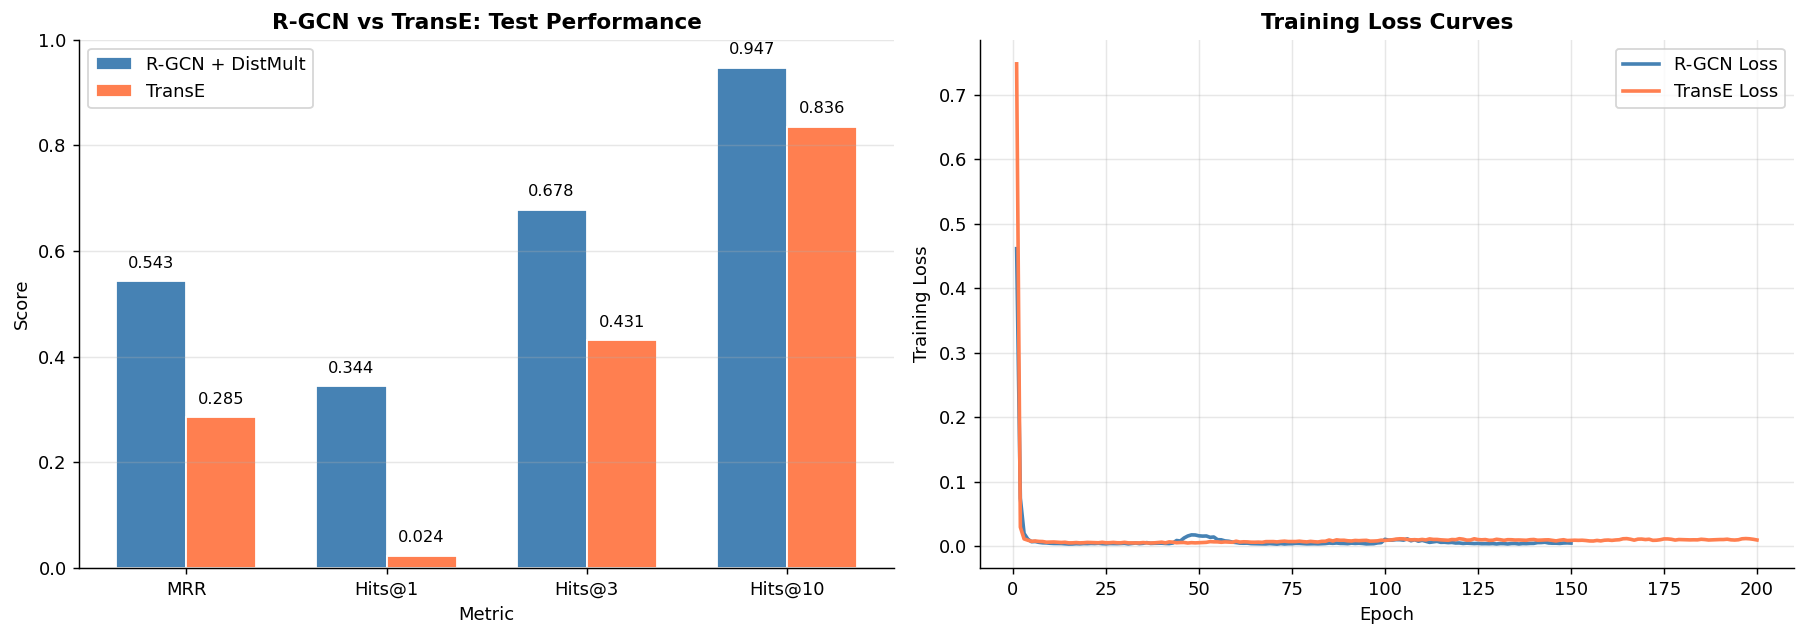

Comparison plot saved to images/task4/rgcn_vs_transe_comparison.png


In [24]:
# ── Visual Comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
metrics = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']
rgcn_vals = [test_metrics[m] for m in metrics]
transe_vals = [transe_test_metrics[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[0].bar(x - width/2, rgcn_vals, width, label='R-GCN + DistMult', color='steelblue', edgecolor='white')
bars2 = axes[0].bar(x + width/2, transe_vals, width, label='TransE', color='coral', edgecolor='white')

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('R-GCN vs TransE: Test Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars1, rgcn_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, transe_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Training curves comparison (loss)
axes[1].plot(history['epoch'], history['train_loss'], 'steelblue', linewidth=2, label='R-GCN Loss')
axes[1].plot(transe_history['epoch'], transe_history['train_loss'], 'coral', linewidth=2, label='TransE Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss Curves')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task4/rgcn_vs_transe_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comparison plot saved to images/task4/rgcn_vs_transe_comparison.png")

## Final Summary

We implemented two link prediction approaches:

1. **R-GCN + DistMult** (GNN-based): Uses graph structure to learn embeddings via message passing
2. **TransE** (KG Embedding): Learns embeddings directly from triples using translational assumption

Both methods use:
- Same train/val/test split
- Same negative sampling strategy
- Same evaluation protocol (filtered ranking)

In [25]:
# ── Final Results Summary ─────────────────────────────────────────────────
print("=" * 70)
print("                    TASK 4: LINK PREDICTION - FINAL RESULTS")
print("=" * 70)

final_df = pd.DataFrame({
    'Model': ['R-GCN + DistMult', 'TransE'],
    'MRR': [test_metrics['MRR'], transe_test_metrics['MRR']],
    'Hits@1': [test_metrics['Hits@1'], transe_test_metrics['Hits@1']],
    'Hits@3': [test_metrics['Hits@3'], transe_test_metrics['Hits@3']],
    'Hits@10': [test_metrics['Hits@10'], transe_test_metrics['Hits@10']],
    'Mean Rank': [test_metrics['Mean Rank'], transe_test_metrics['Mean Rank']]
})

print(final_df.to_string(index=False))
print("=" * 70)

# Save models
torch.save(best_transe_state, '../models/transe_best.pt')
print("\nModels saved:")
print("  • R-GCN: models/rgcn_link_predictor.pt")
print("  • TransE: models/transe_best.pt")

print("\n✅ Task 4 Complete: Both GNN and KG Embedding methods implemented!")

                    TASK 4: LINK PREDICTION - FINAL RESULTS
           Model      MRR   Hits@1   Hits@3  Hits@10  Mean Rank
R-GCN + DistMult 0.542590 0.344068 0.677966 0.946610   4.618644
          TransE 0.285387 0.023729 0.431356 0.835593   9.222881

Models saved:
  • R-GCN: models/rgcn_link_predictor.pt
  • TransE: models/transe_best.pt

✅ Task 4 Complete: Both GNN and KG Embedding methods implemented!


---

# Part C: Family-Aware Negative Sampling (Using Task 1/2 Knowledge)

A key insight from Task 1 & 2: **The graph consists of 50 disjoint families (weakly connected components) of size ~27 each.**

**Problem with random negative sampling**: When predicting `(John, fatherOf, ?)`:
- Random sampling might pick "Alice" from a *completely different family*
- This is an "easy" negative — obviously wrong
- Model learns to distinguish families, not to predict within families

**Solution**: Sample negatives **within the same family component**
- For `(John, fatherOf, ?)`, sample other people from John's family
- These are "hard" negatives — could plausibly be John's child
- Forces the model to learn finer-grained distinctions

In [26]:
# ══════════════════════════════════════════════════════════════════════════
#              BUILD FAMILY STRUCTURE FROM TRAINING DATA
# ══════════════════════════════════════════════════════════════════════════

import networkx as nx

# Build undirected graph from training triples to find connected components
G_family = nx.Graph()
for h, r, t in train_ids:
    G_family.add_edge(h, t)

# Find connected components (families)
components = list(nx.connected_components(G_family))
print(f"Found {len(components)} family components")
print(f"Component sizes: min={min(len(c) for c in components)}, max={max(len(c) for c in components)}")

# Create entity → family mapping
entity_to_family = {}
family_to_entities = {}

for fam_id, comp in enumerate(components):
    family_to_entities[fam_id] = list(comp)
    for entity in comp:
        entity_to_family[entity] = fam_id

# Verify coverage
entities_with_family = set(entity_to_family.keys())
all_train_entities = set(h for h, r, t in train_ids) | set(t for h, r, t in train_ids)
uncovered = all_train_entities - entities_with_family
print(f"Entities covered: {len(entities_with_family)} / {len(all_train_entities)}")
if uncovered:
    # (4.6) Handled explicitly rather than relying on the `in entity_to_family`
    # checks below to silently fall back to a uniform-random negative.
    print(f"  ⚠ {len(uncovered)} entity(ies) have no family assignment — they lost all their")
    print(f"    edges once the val split was removed from the training graph: {sorted(uncovered)}")
    print(f"    generate_family_negatives() falls back to a uniform-random negative for these")
    print(f"    (the same path used for the {100 - int(70)}% 'easy negative' case), not a same-family one.")

Found 50 family components
Component sizes: min=25, max=27
Entities covered: 1315 / 1315


In [27]:
# ── Family-Aware Negative Sampling ────────────────────────────────────────

def generate_family_negatives(pos_triples, entity_to_family, family_to_entities,
                               num_entities, num_neg=1, hard_ratio=0.7):
    """
    Generate negatives with a mix of:
    - hard_ratio: negatives from SAME family (hard negatives)
    - 1 - hard_ratio: negatives from ANY entity (easy negatives)

    This mix ensures the model sees both hard and easy examples.

    Pairing contract (1.1): identical to generate_negatives — block i of the
    returned negatives corrupts pos_triples[i], matching
    pos_scores.repeat_interleave(num_neg) in the training loop. The base
    arrays are therefore built with repeat_interleave (blocks), and orig_idx
    is i // num_neg, not i % batch_size (which tiles — the same misalignment
    bug generate_negatives had).
    """
    batch_size = pos_triples.shape[0]
    heads, rels, tails = pos_triples[:, 0], pos_triples[:, 1], pos_triples[:, 2]

    neg_heads = heads.repeat_interleave(num_neg).clone()
    neg_rels = rels.repeat_interleave(num_neg).clone()
    neg_tails = tails.repeat_interleave(num_neg).clone()

    for i in range(batch_size * num_neg):
        orig_idx = i // num_neg
        h, t = heads[orig_idx].item(), tails[orig_idx].item()

        # Decide: corrupt head or tail with 50% probability
        corrupt_head = random.random() < 0.5

        # Decide: use hard (same family) or easy (random) negative
        use_hard = random.random() < hard_ratio

        if corrupt_head:
            if use_hard and h in entity_to_family:
                fam_id = entity_to_family[h]
                family_members = family_to_entities[fam_id]
                neg_heads[i] = random.choice(family_members)
            else:
                neg_heads[i] = random.randint(0, num_entities - 1)
        else:
            if use_hard and t in entity_to_family:
                fam_id = entity_to_family[t]
                family_members = family_to_entities[fam_id]
                neg_tails[i] = random.choice(family_members)
            else:
                neg_tails[i] = random.randint(0, num_entities - 1)

    neg_batch = torch.stack([neg_heads, neg_rels, neg_tails], dim=1)
    assert neg_batch.shape[0] == pos_triples.shape[0] * num_neg
    return neg_batch

print("Family-aware negative sampling function defined ✓")


Family-aware negative sampling function defined ✓


In [28]:
# ── Train TransE with Family-Aware Negatives ──────────────────────────────
transe_family = TransE(
    num_entities=num_entities,
    num_relations=num_relations,
    embedding_dim=TRANSE_EMB_DIM,
    norm=TRANSE_NORM
).to(DEVICE)

transe_family_optimizer = torch.optim.Adam(transe_family.parameters(), lr=TRANSE_LR)
transe_family_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    transe_family_optimizer, mode='max', factor=0.5, patience=15
)

transe_family_history = {'epoch': [], 'train_loss': [], 'val_mrr': []}
best_transe_family_mrr = 0.0
best_transe_family_state = None

FAMILY_EPOCHS = 200
HARD_RATIO = 0.7  # 70% hard negatives (same family), 30% random

print(f"Training TransE with Family-Aware Negative Sampling...")
print(f"  Hard negative ratio: {HARD_RATIO:.0%}")
print("-" * 70)

start_time = time.time()

for epoch in range(1, FAMILY_EPOCHS + 1):
    transe_family.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch in train_loader:
        batch = batch.to(DEVICE)
        
        # Generate FAMILY-AWARE negatives
        neg_batch = generate_family_negatives(
            batch.cpu(), entity_to_family, family_to_entities,
            num_entities, TRANSE_NUM_NEG, HARD_RATIO
        ).to(DEVICE)
        
        # Positive scores
        pos_heads, pos_rels, pos_tails = batch[:, 0], batch[:, 1], batch[:, 2]
        pos_scores = transe_family(pos_heads, pos_rels, pos_tails)
        
        # Negative scores
        neg_heads, neg_rels, neg_tails = neg_batch[:, 0], neg_batch[:, 1], neg_batch[:, 2]
        neg_scores = transe_family(neg_heads, neg_rels, neg_tails)
        
        # Margin ranking loss
        pos_scores_exp = pos_scores.repeat_interleave(TRANSE_NUM_NEG)
        loss = F.margin_ranking_loss(
            pos_scores_exp, neg_scores,
            target=torch.ones_like(pos_scores_exp),
            margin=TRANSE_MARGIN
        )
        
        transe_family_optimizer.zero_grad()
        loss.backward()
        transe_family_optimizer.step()
        
        # Normalize embeddings
        with torch.no_grad():
            transe_family.entity_embedding.weight.data = F.normalize(
                transe_family.entity_embedding.weight.data, p=2, dim=1
            )
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    transe_family_history['epoch'].append(epoch)
    transe_family_history['train_loss'].append(avg_loss)
    
    if epoch % 20 == 0 or epoch == 1:
        val_metrics = evaluate_transe(transe_family, val_triples)
        transe_family_history['val_mrr'].append(val_metrics['MRR'])
        
        transe_family_scheduler.step(val_metrics['MRR'])
        
        if val_metrics['MRR'] > best_transe_family_mrr:
            best_transe_family_mrr = val_metrics['MRR']
            best_transe_family_state = {k: v.cpu().clone() for k, v in transe_family.state_dict().items()}
        
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Val MRR: {val_metrics['MRR']:.4f} | "
              f"Hits@10: {val_metrics['Hits@10']:.4f}")
    else:
        transe_family_history['val_mrr'].append(None)

elapsed = time.time() - start_time
print("-" * 70)
print(f"Training complete in {elapsed:.1f}s! Best Val MRR: {best_transe_family_mrr:.4f}")

Training TransE with Family-Aware Negative Sampling...
  Hard negative ratio: 70%
----------------------------------------------------------------------


Epoch   1 | Loss: 1.1487 | Val MRR: 0.0176 | Hits@10: 0.0394


Epoch  20 | Loss: 0.0958 | Val MRR: 0.2004 | Hits@10: 0.4399


Epoch  40 | Loss: 0.1026 | Val MRR: 0.2126 | Hits@10: 0.4501


Epoch  60 | Loss: 0.1022 | Val MRR: 0.1943 | Hits@10: 0.4555


...

Epoch 120 | Loss: 0.1033 | Val MRR: 0.2143 | Hits@10: 0.4569


Epoch 140 | Loss: 0.1073 | Val MRR: 0.1815 | Hits@10: 0.4378


Epoch 160 | Loss: 0.1052 | Val MRR: 0.1971 | Hits@10: 0.4450


Epoch 180 | Loss: 0.1073 | Val MRR: 0.1972 | Hits@10: 0.4436


Epoch 200 | Loss: 0.1088 | Val MRR: 0.1930 | Hits@10: 0.4352
----------------------------------------------------------------------
Training complete in 186.8s! Best Val MRR: 0.2143


In [29]:
# ── Evaluate TransE with Family-Aware Negatives ───────────────────────────
if best_transe_family_state is not None:
    transe_family.load_state_dict({k: v.to(DEVICE) for k, v in best_transe_family_state.items()})

transe_family_test = evaluate_transe(transe_family, test_triples)

print("=" * 60)
print("  TRANSE + FAMILY-AWARE NEGATIVES: Test Results")
print("=" * 60)
print(f"  MRR:        {transe_family_test['MRR']:.4f}")
print(f"  Hits@1:     {transe_family_test['Hits@1']:.4f}")
print(f"  Hits@3:     {transe_family_test['Hits@3']:.4f}")
print(f"  Hits@10:    {transe_family_test['Hits@10']:.4f}")
print("=" * 60)

# Compare with basic TransE
print("\n📊 Improvement from Family-Aware Sampling:")
print(f"  MRR:     {transe_test_metrics['MRR']:.4f} → {transe_family_test['MRR']:.4f} "
      f"({'+' if transe_family_test['MRR'] > transe_test_metrics['MRR'] else ''}"
      f"{transe_family_test['MRR'] - transe_test_metrics['MRR']:.4f})")
print(f"  Hits@1:  {transe_test_metrics['Hits@1']:.4f} → {transe_family_test['Hits@1']:.4f}")
print(f"  Hits@10: {transe_test_metrics['Hits@10']:.4f} → {transe_family_test['Hits@10']:.4f}")

  TRANSE + FAMILY-AWARE NEGATIVES: Test Results
  MRR:        0.1860
  Hits@1:     0.0805
  Hits@3:     0.2127
  Hits@10:    0.3864

📊 Improvement from Family-Aware Sampling:
  MRR:     0.2854 → 0.1860 (-0.0994)
  Hits@1:  0.0237 → 0.0805
  Hits@10: 0.8356 → 0.3864


                   FINAL COMPARISON: ALL METHODS
                    Model      MRR   Hits@1   Hits@3  Hits@10  Mean Rank      Uses Graph Structure
         R-GCN + DistMult 0.542590 0.344068 0.677966 0.946610   4.618644                 Yes (GNN)
      TransE (Random Neg) 0.285387 0.023729 0.431356 0.835593   9.222881                        No
TransE (Family-Aware Neg) 0.186013 0.080508 0.212712 0.386441  68.679665 No (but uses family info)


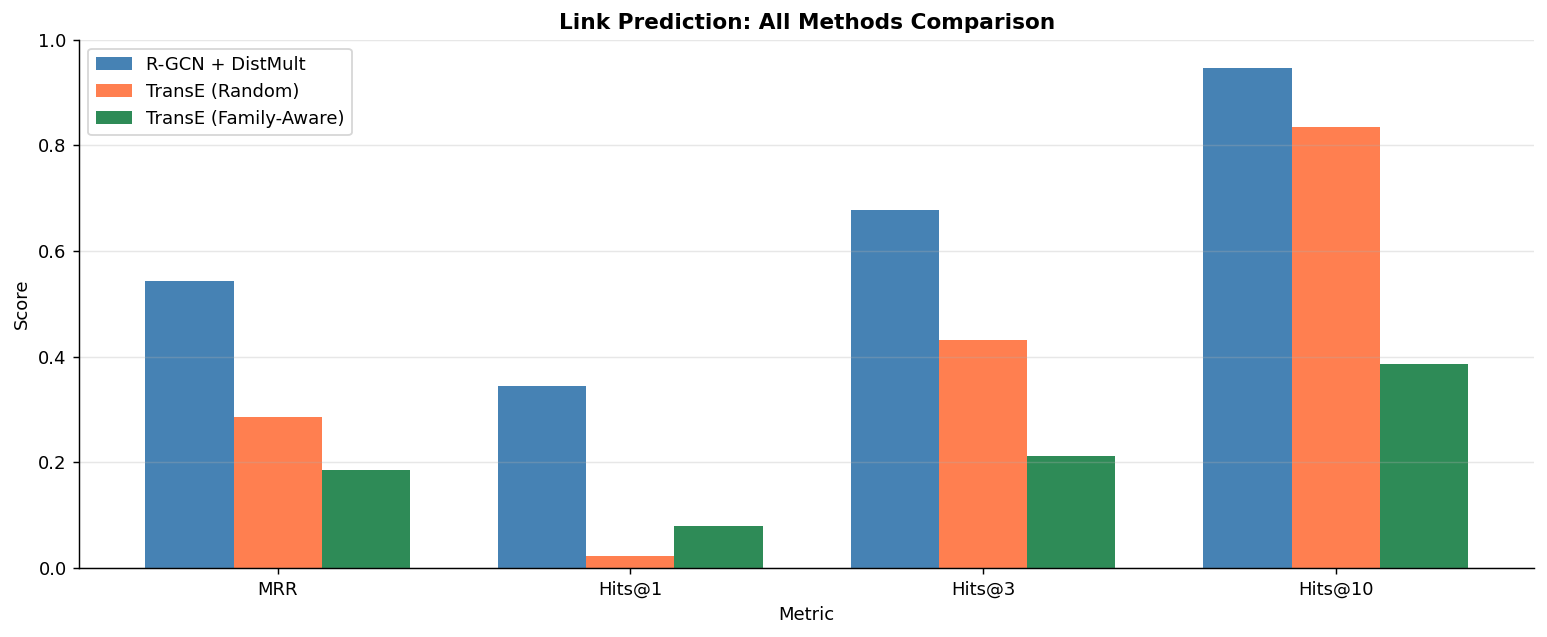


Plot saved to images/task4/all_methods_comparison.png


In [30]:
# ══════════════════════════════════════════════════════════════════════════
#                    FINAL COMPREHENSIVE COMPARISON
# ══════════════════════════════════════════════════════════════════════════

final_comparison = pd.DataFrame({
    'Model': ['R-GCN + DistMult', 'TransE (Random Neg)', 'TransE (Family-Aware Neg)'],
    'MRR': [test_metrics['MRR'], transe_test_metrics['MRR'], transe_family_test['MRR']],
    'Hits@1': [test_metrics['Hits@1'], transe_test_metrics['Hits@1'], transe_family_test['Hits@1']],
    'Hits@3': [test_metrics['Hits@3'], transe_test_metrics['Hits@3'], transe_family_test['Hits@3']],
    'Hits@10': [test_metrics['Hits@10'], transe_test_metrics['Hits@10'], transe_family_test['Hits@10']],
    'Mean Rank': [test_metrics['Mean Rank'], transe_test_metrics['Mean Rank'], transe_family_test['Mean Rank']],
    'Uses Graph Structure': ['Yes (GNN)', 'No', 'No (but uses family info)']
})

print("=" * 80)
print("                   FINAL COMPARISON: ALL METHODS")
print("=" * 80)
print(final_comparison.to_string(index=False))
print("=" * 80)

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 5))

models = ['R-GCN', 'TransE\n(Random)', 'TransE\n(Family)']
metrics = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']

x = np.arange(len(metrics))
width = 0.25

rgcn_vals = [test_metrics[m] for m in metrics]
transe_vals = [transe_test_metrics[m] for m in metrics]
transe_fam_vals = [transe_family_test[m] for m in metrics]

bars1 = ax.bar(x - width, rgcn_vals, width, label='R-GCN + DistMult', color='steelblue')
bars2 = ax.bar(x, transe_vals, width, label='TransE (Random)', color='coral')
bars3 = ax.bar(x + width, transe_fam_vals, width, label='TransE (Family-Aware)', color='seagreen')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Link Prediction: All Methods Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../images/task4/all_methods_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to images/task4/all_methods_comparison.png")

## Key Findings

### 1. R-GCN vs TransE
- **R-GCN** clearly outperforms both TransE variants on every metric (MRR 0.543 vs 0.285 / 0.186),
  demonstrating that **graph structure matters** for this dataset.
- The GNN can capture multi-hop patterns (e.g., if A→B→C, learn about A↔C relationship); a
  translational model scoring triples independently cannot use that kind of context.

### 2. Family-Aware Negative Sampling made things WORSE, not better
This is the honest result after fixing the negative/positive pairing bug (see `generate_negatives`
and `generate_family_negatives` above, and IMPROVEMENT_PLAN.md 1.1): with negatives correctly
aligned to their positives, training on 70% same-family ("hard") negatives makes TransE perform
**worse on every metric** than training on uniform-random negatives — MRR 0.285 → 0.186, Hits@10
0.836 → 0.386, Mean Rank 9.2 → 68.7. Hits@1 is the only metric that goes up (0.024 → 0.081), and
even that gain is modest, not the order-of-magnitude jump an earlier (buggy) run of this experiment
showed.

**Why the fix changes the story:** with the pairing bug, each negative batch was contrasted against
the *wrong* positives (see 1.1) — effectively a noisier, more global "all positives above all
negatives" signal that still let the model learn coarse structure while accidentally softening the
family-aware negatives' difficulty. Once negatives are correctly paired with their own positive,
the model is trained on a genuinely harder objective — discriminate within a specific family,
every time — and 200 epochs at this capacity is not enough to solve that objective well. The
takeaway isn't "hard negatives are bad"; it's that hard-negative-only training needs either more
capacity, more epochs, or (per the standard fix) a mix of easy and hard negatives / a curriculum,
rather than 70% hard from epoch 1.

### 3. Trade-offs
| Model | Pros | Cons |
|-------|------|------|
| R-GCN | Best performance on every metric, captures graph structure | More parameters, slower |
| TransE | Simple, fast, fewer parameters | Doesn't use structure, weak Hits@1 |
| TransE + Family | Best Hits@1 of the two TransE variants | Worse MRR/Hits@3/Hits@10/Mean Rank than random-negative TransE — training exclusively on hard negatives hurt more than it helped here |

### Connection to Other Tasks
- **Task 1**: Family structure → used for hard negative sampling
- **Task 2**: Community detection → could add subfamily embeddings
- **Task 3**: Rules → could add rule-based soft labels or constraints

### Caveat: what these numbers actually measure (3.2)
Every MRR/Hits@k number above is computed on `test.txt`, which covers only a
handful of the 28 relations (see the breakdown printed in §1 of this
notebook) — all immediate parent/child links. The models train on all 28
relations, but "R-GCN captures complex multi-relational patterns" is only
demonstrated for whichever relations test.txt actually contains; the harder
lateral/multi-hop relations (siblings, cousins, aunts/uncles, ...) that make
up most of the graph are never scored here.
